In [31]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aditisaxena20/superstore-sales-dataset")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\Han\.cache\kagglehub\datasets\aditisaxena20\superstore-sales-dataset\versions\1


In [32]:
import pandas as pd

# Read the CSV file
df = pd.read_csv(path + '\\SuperStore_Orders.csv', encoding='latin-1')

# Display the first few rows of the dataframe
print(df.head(100))

           order_id  order_date   ship_date       ship_mode     customer_name  \
0      AG-2011-2040  01-01-2011  06-01-2011  Standard Class   Toby Braunhardt   
1     IN-2011-47883  01-01-2011  08-01-2011  Standard Class       Joseph Holt   
2      HU-2011-1220  01-01-2011  05-01-2011    Second Class     Annie Thurman   
3   IT-2011-3647632  01-01-2011  05-01-2011    Second Class      Eugene Moren   
4     IN-2011-47883  01-01-2011  08-01-2011  Standard Class       Joseph Holt   
..              ...         ...         ...             ...               ...   
95    IN-2011-69366  09-01-2011  14-01-2011  Standard Class   Alejandro Grove   
96    ID-2011-46483  09-01-2011  13-01-2011  Standard Class  Sample Company A   
97    IN-2011-69366  09-01-2011  14-01-2011  Standard Class   Alejandro Grove   
98    ID-2011-46483  09-01-2011  13-01-2011  Standard Class  Sample Company A   
99    IN-2011-69366  09-01-2011  14-01-2011  Standard Class   Alejandro Grove   

        segment            

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [34]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [35]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


Key Statistics:
Total Sales: $12,642,905.00
Total Profit: $1,469,034.82
Average Discount: 14.29%
Most Common Ship Mode: Standard Class


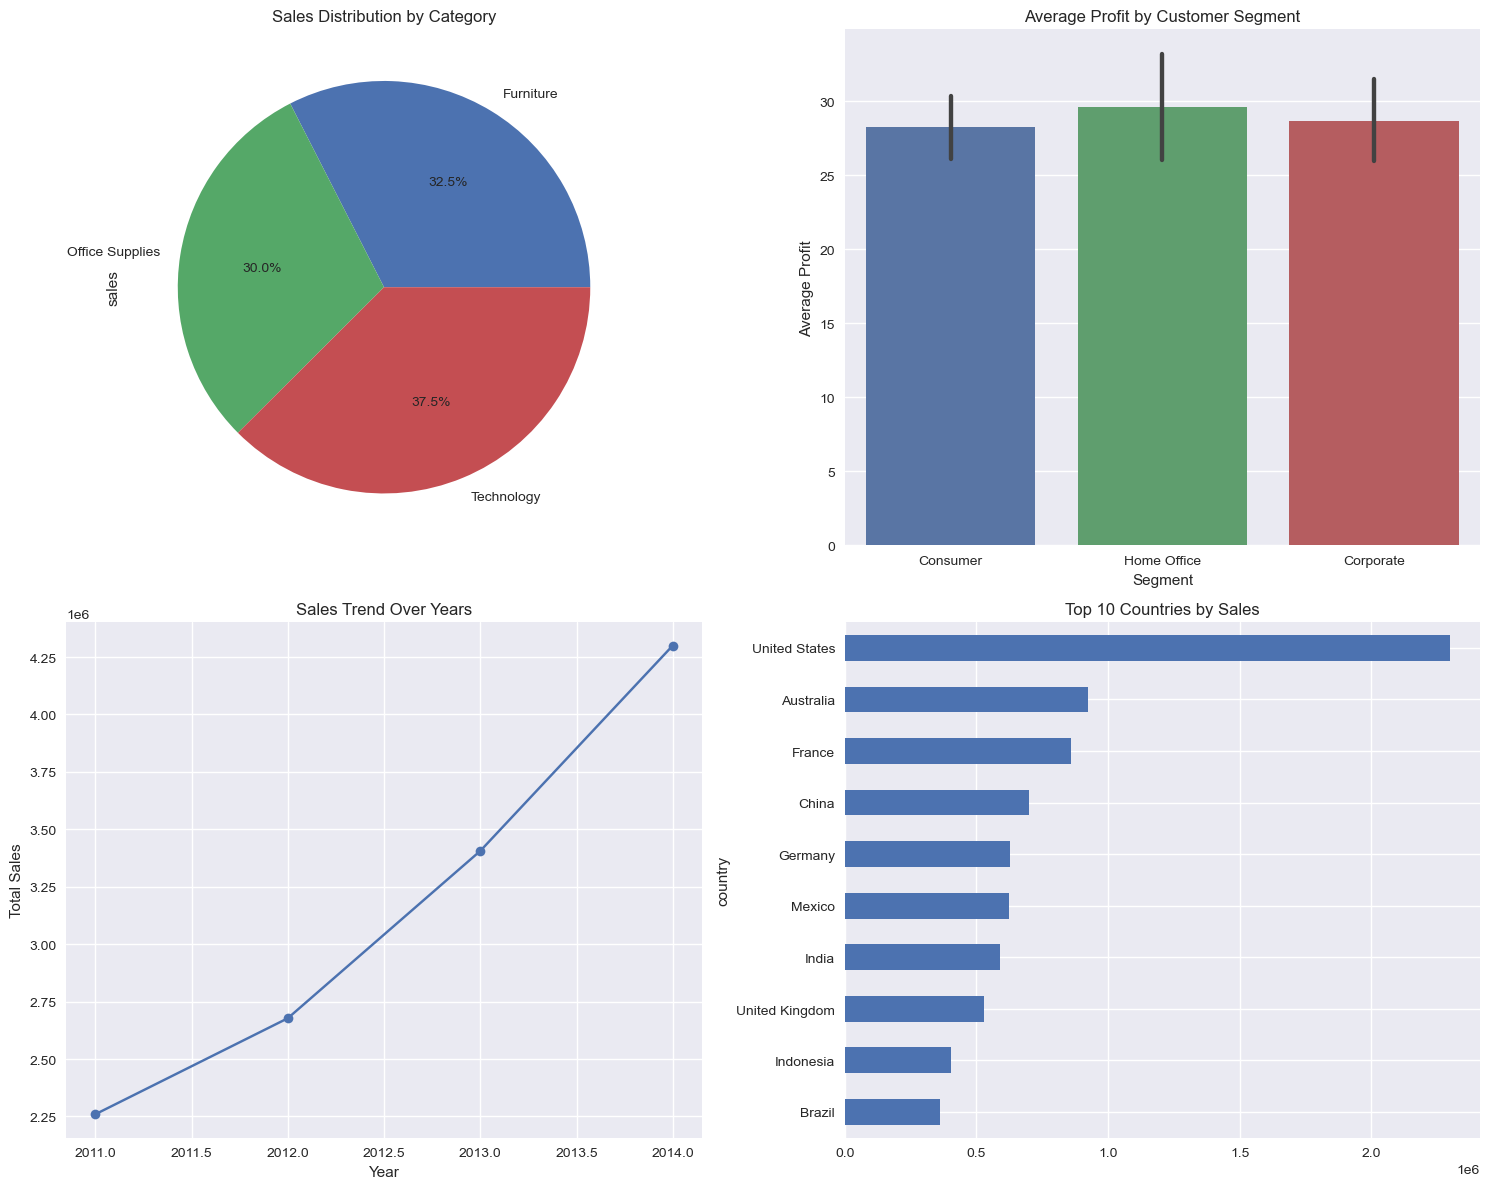

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better visualization
plt.style.use('seaborn-v0_8')  # or you can use 'seaborn-darkgrid'
# Convert sales to float at the beginning
# df['sales'] = df['sales'].str.replace('$', '').str.replace(',', '').astype(float)


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sales by Category
df.groupby('category')['sales'].sum().astype(float).plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,0], title='Sales Distribution by Category')

# 2. Average Profit by Segment
sns.barplot(data=df, x='segment', y='profit', ax=axes[0,1])
axes[0,1].set_title('Average Profit by Customer Segment')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Average Profit')

# 3. Sales Trend Over Years
yearly_sales = df.groupby('year')['sales'].sum().astype(float)
yearly_sales.plot(kind='line', marker='o', ax=axes[1,0])
axes[1,0].set_title('Sales Trend Over Years')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Sales')

# 4. Top 10 Countries by Sales
top_countries = df.groupby('country')['sales'].sum().astype(float).sort_values(ascending=True)[-10:]
top_countries.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top 10 Countries by Sales')

plt.tight_layout()

# Print key statistics
print("\nKey Statistics:")
print(f"Total Sales: ${df['sales'].astype(float).sum():,.2f}")
print(f"Total Profit: ${df['profit'].sum():,.2f}")
print(f"Average Discount: {df['discount'].mean():.2%}")
print(f"Most Common Ship Mode: {df['ship_mode'].mode()[0]}")